# RNA implementation to SCICoNE

In [1]:
#import libraries

import scicone
import numpy as np
import pickle
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import io
import scanpy as sc
import anndata
import pyranges
import gseapy as gp

# Set up SCICoNE
install_path = '/cluster/work/bewi/members/andress/pylabs/SCICoNE/build/'
install_path_local = "/home/andress/pylabs/SCICoNE_lab/build/"
temporary_outpath = './'

seed = 42 # for reproducibility

np.random.seed(seed)

# Create SCICoNE object
sci = scicone.SCICoNE(install_path_local, temporary_outpath, verbose=False)

Using binaries at /home/andress/pylabs/SCICoNE_lab/build/


In [2]:


# Define paths
scdna_path_ssh = '/cluster/work/bewi/members/andress/SCICoNE_lab/rna_imp/clonealign-processed-data/SA501/cnv/'
scrna_path_ssh = '/cluster/work/bewi/members/andress/SCICoNE_lab/rna_imp/clonealign-processed-data/SA501/10X/20171026_SA501X2XB00096/outs/filtered_gene_bc_matrices/hg19/'

scdna_path_local = '/home/andress/pylabs/SCICoNE_lab/rna_imp/SA501/cnv'
scrna_path_local = '/home/andress/pylabs/SCICoNE_lab/rna_imp/SA501/10X/20171026_SA501X2XB00096/outs/filtered_gene_bc_matrices/hg19'

# Try SSH paths first
try:
    if os.path.exists(scdna_path_ssh) and os.path.exists(scrna_path_ssh):
        scdna_path = scdna_path_ssh
        scrna_path = scrna_path_ssh
    else:
        raise FileNotFoundError("SSH paths are not accessible.")
except FileNotFoundError:
    # Use local paths
    if os.path.exists(scdna_path_local) and os.path.exists(scrna_path_local):
        scdna_path = scdna_path_local
        scrna_path = scrna_path_local
    else:
        raise FileNotFoundError("Neither SSH nor local paths are accessible.")

In [3]:
annot = sc.queries.biomart_annotations(
        "hsapiens",
        ["ensembl_gene_id", "start_position", "end_position", "chromosome_name"],
    ).set_index("ensembl_gene_id")

annot = annot.reset_index()
annot = annot.rename(columns={'start_position':'Start', 'end_position': 'End', 'chromosome_name': 'Chromosome'})

gr_annotations = pyranges.from_dict(annot.to_dict())

gr_annotations.head()


,ensembl_gene_id,Start,End,Chromosome
0,ENSG00000142611,3069168,3438621,1
1,ENSG00000284616,5301928,5307394,1
2,ENSG00000157911,2403964,2413797,1
3,ENSG00000260972,5492978,5494674,1
4,ENSG00000224340,10054445,10054781,1
5,ENSG00000229280,4175528,4175899,1
6,ENSG00000142655,10472288,10630758,1
7,ENSG00000232596,4571481,4594016,1


In [11]:
# Convert PyRanges object to a pandas DataFrame
gr_annotations_df = gr_annotations.df

# Save the DataFrame as a CSV file
gr_annotations_df.to_csv(os.path.join(temporary_outpath, 'gr_annotations.csv'), index=False)

# Read scRNA data

In [4]:
#read data

mat = io.mmread(f'{scrna_path}/matrix.mtx').toarray()
barcodes = pd.read_csv(f'{scrna_path}/barcodes.tsv', sep='\t', header=None)
genes = pd.read_csv(f'{scrna_path}/genes.tsv', sep='\t', header=None)


In [5]:
adata = anndata.AnnData(pd.DataFrame(mat.T, index=barcodes[0].values, columns=genes[0].values))
adata.var_names_make_unique()
adata.var['ensembl_gene_id'] = genes[0].values
adata.var['gene_id'] = genes[1].values
print(adata.obs_names[:5])  # First 5 observation names (e.g., barcodes)
print(adata.var_names[:5])  # First 5 variable names (e.g., gene names)
print(adata.shape)  # Should return (number of cells, number of genes)

Index(['AAACCTGAGATCCGAG-1', 'AAACCTGAGATGCCAG-1', 'AAACCTGTCGACAGCC-1',
       'AAACCTGTCTTCAACT-1', 'AAACGGGAGCAATCTC-1'],
      dtype='object')
Index(['ENSG00000243485', 'ENSG00000237613', 'ENSG00000186092',
       'ENSG00000238009', 'ENSG00000239945'],
      dtype='object')
(2470, 32738)


# Pre-processing 

In [6]:
#basic filtering

sc.pp.filter_cells(adata, min_genes=200)    
sc.pp.filter_genes(adata, min_cells=3)

In [8]:
#save adata
adata.write(f'{temporary_outpath}/adatas/adata_basic.h5ad')

In [7]:
#RESET DATA

adata = anndata.read_h5ad(f'{temporary_outpath}/adatas/adata_basic.h5ad')

In [8]:
#filter based on mithocondrial genes 

adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
adata = adata[adata.obs.n_genes_by_counts < 2500, :] #doublets 
adata = adata[adata.obs.pct_counts_mt < 5, :] #mitochondrial quality control

adata

View of AnnData object with n_obs × n_vars = 1537 × 17907
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'ensembl_gene_id', 'gene_id', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [9]:
df_annotations = gr_annotations.df.set_index('ensembl_gene_id')

df_exp_annotations = df_annotations.loc[df_annotations.index.intersection(adata.var['ensembl_gene_id'])]\
                        .reset_index().rename(columns={'index':'ensembl_gene_id'})


#filter out genes with no annotation
adata.var_names = adata.var['ensembl_gene_id'].values

adata = adata[:,df_exp_annotations['ensembl_gene_id']]

adata

View of AnnData object with n_obs × n_vars = 1537 × 17152
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'ensembl_gene_id', 'gene_id', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [12]:
#sort by chromosome and end position

adata.var = adata.var.merge(gr_annotations_df[['ensembl_gene_id', 'Chromosome', 'End']], 
                            on='ensembl_gene_id', how='left')

print(adata.var.columns)

adata.var['Chromosome'] = adata.var['Chromosome'].astype(str)  # Convert Chromosome to string

# Sort adata.var by Chromosome and End
sorted_var = adata.var.sort_values(by=['Chromosome', 'End'])

# Reorder adata.X columns based on the sorted var index
adata = adata[:, sorted_var.index]

adata

Index(['ensembl_gene_id', 'gene_id', 'n_cells', 'mt', 'n_cells_by_counts',
       'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'Chromosome',
       'End'],
      dtype='object')


View of AnnData object with n_obs × n_vars = 1537 × 17152
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'ensembl_gene_id', 'gene_id', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'Chromosome', 'End'

In [13]:
#Save pre_processed data
adata.write(f'{temporary_outpath}/adatas/adata_mt_filtered.h5ad')

/home/andress/miniconda3/envs/scicone_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  df[key] = c
/home/andress/miniconda3/envs/scicone_env/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [14]:
#RESEEEEET data to pre processed data
adata = anndata.read_h5ad('/home/andress/pylabs/SCICoNE_lab/rna_imp/adatas/adata_mt_filtered.h5ad')
adata

AnnData object with n_obs × n_vars = 1537 × 17152
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'ensembl_gene_id', 'gene_id', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'Chromosome', 'End'

In [6]:
adata.raw = adata.copy()  # Set raw counts for later use
print("Raw counts saved to adata.raw")

Raw counts saved to adata.raw


/home/andress/miniconda3/envs/scicone_env/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:709: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/andress/miniconda3/envs/scicone_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_6205/4225172293.py:10: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=5.0)


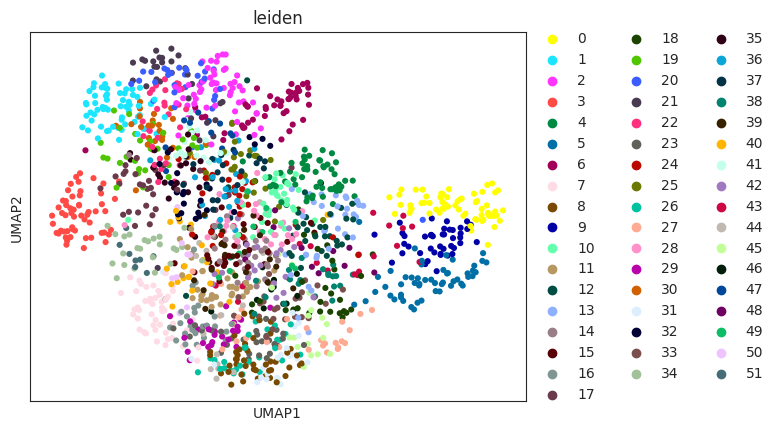

Number of clusters: 52
Reset to raw counts.


In [7]:
#Normalize and preprocess the data
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata = adata[:, adata.var.highly_variable]
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.leiden(adata, resolution=5.0)

sc.tl.umap(adata)  # Compute UMAP
sc.pl.umap(adata, color='leiden')  # Visualize UMAP with clusters

# Save clustering results
num_clusters = adata.obs['leiden'].nunique()
print(f"Number of clusters: {num_clusters}")

if adata.raw is not None:
    adata = adata.raw.to_adata()  # Reset to raw counts
    print("Reset to raw counts.")
else:
    raise ValueError("adata.raw is not set. Ensure raw counts are saved before preprocessing.")

adata
adata.write(f'{temporary_outpath}/adatas/adata_leiden.h5ad')



# Create Cluster-based AnnData Objects

In [10]:
# Load the preprocessed AnnData object
import scipy.sparse  # Add missing import
adata = anndata.read_h5ad(f'{temporary_outpath}/adatas/adata_leiden.h5ad')

# Get cluster assignments
cluster_labels = adata.obs['leiden']
unique_clusters = np.unique(cluster_labels)

# Initialize lists to store the aggregated values
clusters_sum = []
clusters_mean = []
clusters_median = []
cluster_names = []

# For each cluster, compute sum, mean, and median
for cluster in unique_clusters:
    # Get cells belonging to this cluster
    cells_in_cluster = adata[cluster_labels == cluster]
    
    # Compute aggregates
    sum_expr = cells_in_cluster.X.sum(axis=0)
    mean_expr = cells_in_cluster.X.mean(axis=0)
    median_expr = np.median(cells_in_cluster.X, axis=0)
    
    # Convert matrices to 1D arrays if needed
    if scipy.sparse.issparse(sum_expr):
        sum_expr = sum_expr.A1
        mean_expr = mean_expr.A1
    else:
        sum_expr = np.array(sum_expr).flatten()
        mean_expr = np.array(mean_expr).flatten()
        median_expr = np.array(median_expr).flatten()
    
    # Store values
    clusters_sum.append(sum_expr)
    clusters_mean.append(mean_expr)
    clusters_median.append(median_expr)
    
    # Create descriptive name with cell count
    cell_count = np.sum(cluster_labels == cluster)
    cluster_names.append(f"Cluster {cluster} ({cell_count} cells)")

# Create AnnData objects for each aggregation method
adata_sum = anndata.AnnData(
    X=np.vstack(clusters_sum),
    obs=pd.DataFrame(index=cluster_names),
    var=adata.var
)

adata_mean = anndata.AnnData(
    X=np.vstack(clusters_mean),
    obs=pd.DataFrame(index=cluster_names),
    var=adata.var
)

adata_median = anndata.AnnData(
    X=np.vstack(clusters_median),
    obs=pd.DataFrame(index=cluster_names),
    var=adata.var
)

# Add cluster information to obs
for cluster_adata in [adata_sum, adata_mean, adata_median]:
    cluster_adata.obs['cluster'] = [name.split('(')[0].strip() for name in cluster_names]
    cluster_adata.obs['n_cells'] = [int(name.split('(')[1].split()[0]) for name in cluster_names]

# Save the resulting AnnData objects
adata_sum.write_h5ad(f'{temporary_outpath}/adatas/adata_clusters_sum.h5ad')
adata_mean.write_h5ad(f'{temporary_outpath}/adatas/adata_clusters_mean.h5ad')
adata_median.write_h5ad(f'{temporary_outpath}/adatas/adata_clusters_median.h5ad')

print(f"Created and saved cluster-level AnnData objects with {len(unique_clusters)} clusters.")
print(f"Sum dimensions: {adata_sum.shape}")
print(f"Mean dimensions: {adata_mean.shape}")
print(f"Median dimensions: {adata_median.shape}")

Created and saved cluster-level AnnData objects with 52 clusters.
Sum dimensions: (52, 17153)
Mean dimensions: (52, 17153)
Median dimensions: (52, 17153)


In [16]:
# Check if cluster_file.X is formatted like filtered_counts
for cluster_file in [adata_mean, adata_median, adata_sum]:
    print(f"Checking cluster_file: {cluster_file}")
    print(f"Type of cluster_file.X: {type(cluster_file.X)}")
    print(f"Shape of cluster_file.X: {cluster_file.X.shape}")
    print(f"Content of cluster_file.X (first 5 rows):\n{cluster_file.X[:5]}")
    print("\n")

Checking cluster_file: AnnData object with n_obs × n_vars = 52 × 17153
    obs: 'cluster', 'n_cells'
    var: 'ensembl_gene_id', 'gene_id', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'Chromosome', 'End'
Type of cluster_file.X: <class 'numpy.ndarray'>
Shape of cluster_file.X: (52, 17153)
Content of cluster_file.X (first 5 rows):
[[0.06451613 0.         0.         ... 0.         0.01612903 0.        ]
 [0.1147541  0.         0.         ... 0.         0.         0.        ]
 [0.11111111 0.         0.         ... 0.         0.         0.        ]
 [0.14285714 0.02857143 0.         ... 0.         0.         0.        ]
 [0.14705882 0.         0.         ... 0.         0.         0.        ]]


Checking cluster_file: AnnData object with n_obs × n_vars = 52 × 17153
    obs: 'cluster', 'n_cells'
    var: 'ensembl_gene_id', 'gene_id', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'Chromosome', 'En

In [ ]:
# Get gene coordinates

adata = anndata.read_h5ad(f'{temporary_outpath}/adatas/adata_clustered.h5ad')
df_annotations = gr_annotations.df.set_index('ensembl_gene_id')

df_exp_annotations = df_annotations.loc[df_annotations.index.intersection(adata.var['ensembl_gene_id'])]\
                        .reset_index().rename(columns={'index':'ensembl_gene_id'})

adata.var_names = adata.var['ensembl_gene_id'].values

adata = adata[:,df_exp_annotations['ensembl_gene_id']]

df_exp_annotations_sorted = df_exp_annotations.sort_values(by=['Chromosome', 'End'])

df_exp_annotations_sorted.head()

In [ ]:
# Use raw counts for meta-cell construction
raw_adata = adata.raw.to_adata()
cluster_labels = adata.obs['leiden']
unique_clusters = cluster_labels.unique()

meta_cells_sum = []
meta_cells_mean = []
meta_cells_median = []
meta_cell_names = []

for cluster in unique_clusters:
    cluster_indices = np.where(cluster_labels == cluster)[0]
    cluster_data = raw_adata.X[cluster_indices]

    # Sum raw counts for each cluster
    cluster_sum = cluster_data.sum(axis=0)
    meta_cells_sum.append(cluster_sum)

    # Mean raw counts for each cluster
    cluster_mean = cluster_data.mean(axis=0)
    meta_cells_mean.append(cluster_mean)

    # Median raw counts for each cluster
    cluster_median = np.median(cluster_data, axis=0)
    meta_cells_median.append(cluster_median)

    num_cells = len(cluster_indices)
    meta_cell_names.append(f'Cluster {cluster} ({num_cells} cells)')

# Convert to new AnnData objects
meta_cells_sum_matrix = np.vstack(meta_cells_sum)
meta_cells_mean_matrix = np.vstack(meta_cells_mean)
meta_cells_median_matrix = np.vstack(meta_cells_median)

meta_adata_sum = anndata.AnnData(X=meta_cells_sum_matrix)
meta_adata_mean = anndata.AnnData(X=meta_cells_mean_matrix)
meta_adata_median = anndata.AnnData(X=meta_cells_median_matrix)

# Add metadata
for meta_adata in [meta_adata_sum, meta_adata_mean, meta_adata_median]:
    meta_adata.obs['cluster'] = meta_cell_names
    meta_adata.obs_names = meta_cell_names  # Set obs_names to include cluster number and cell count
    meta_adata.var = raw_adata.var.copy()  # Copy gene metadata from raw counts

    # Sort by chromosome and end position
    meta_adata.var = meta_adata.var.merge(
        df_annotations[['Chromosome', 'End']],
        how='left',
        left_on='ensembl_gene_id',
        right_index=True
    )
    meta_adata.var = meta_adata.var.sort_values(by=['Chromosome', 'End']).reset_index(drop=True)
    meta_adata = meta_adata[:, meta_adata.var.index]

# Save the meta cells AnnData objects
meta_adata_sum.write_h5ad(f'{temporary_outpath}/clusters_sum.h5ad')
meta_adata_mean.write_h5ad(f'{temporary_outpath}/clusters_mean.h5ad')
meta_adata_median.write_h5ad(f'{temporary_outpath}/clusters_median.h5ad')

print("Meta cells created, sorted, and saved:")
print("Sum:", meta_adata_sum)
print("Mean:", meta_adata_mean)
print("Median:", meta_adata_median)

In [ ]:
# # Compute smoothed average for meta cells
# import numpy as np

# def compute_smoothed_average(meta_adata, window_size=10):
#     """
#     Compute smoothed average for a cluster-by-gene counts matrix.
    
#     Parameters:
#     -----------
#     meta_adata : AnnData
#         AnnData object containing the cluster-by-gene counts matrix.
#     window_size : int
#         Size of the sliding window for smoothing.
    
#     Returns:
#     # --------
#     AnnData
#         Updated AnnData object with smoothed counts.
#     """
#     smoothed_matrix = np.zeros_like(meta_adata.X)
#     half_window = window_size // 2
    
#     for i in range(meta_adata.shape[1]):  # Iterate over genes
#         left = max(0, i - half_window)
#         right = min(i + half_window + 1, meta_adata.shape[1])
#         smoothed_matrix[:, i] = meta_adata.X[:, left:right].mean(axis=1)
    
#     meta_adata.X = smoothed_matrix  # Replace the counts matrix with the smoothed matrix
#     return meta_adata

# # Load meta cells
# meta_adata = anndata.read_h5ad('/cluster/work/bewi/members/andress/SCICoNE_lab/rna_imp/meta_cells.h5ad')

# # Apply smoothing
# meta_adata = compute_smoothed_average(meta_adata, window_size=10)

# # Save the smoothed meta cells
# meta_adata.write_h5ad('/cluster/work/bewi/members/andress/SCICoNE_lab/rna_imp/meta_cells_smoothed.h5ad')

# print("Smoothed average computed and saved.")

In [ ]:
chrom_stops = pd.read_csv((os.path.join(temporary_outpath, 'chromosome_stops.csv')), sep=',')
chromosome_stops_list = chrom_stops['Chromosome_stops'].tolist()
# Convert to a flat list
chromosome_stops = [int(i) for i in chromosome_stops_list]

print(chromosome_stops)

Sort Data by Genomic Position and Prepare for SCICoNE

In [ ]:
# Add 'Chromosome', 'Start', and 'End' to adata_clustered.var
adata_clustered = anndata.read_h5ad(f'{temporary_outpath}/adata_clustered.h5ad')

# Perform a left merge to retain all rows in adata_clustered.var
merged_var = adata_clustered.var.merge(
    df_annotations[['Chromosome', 'Start', 'End']],
    how='left',
    left_on='ensembl_gene_id',
    right_index=True
)

# Ensure the index matches the original var index
merged_var.index = adata_clustered.var.index
adata_clustered.var = merged_var

# Verify the updated var
print(adata_clustered.var[['Chromosome', 'Start', 'End']].head())

In [ ]:
# Create a dictionary mapping chromosomes to their respective genes
chrs_dict = {}

# Filter for standard chromosomes
standard_chromosomes = [str(i) for i in range(1, 23)] + ['X', 'Y']
filtered_annotations = gr_annotations.df[gr_annotations.df['Chromosome'].isin(standard_chromosomes)]

# Group genes by chromosome
for chromosome in standard_chromosomes:
    genes_in_chr = filtered_annotations[filtered_annotations['Chromosome'] == chromosome]['ensembl_gene_id'].tolist()
    chrs_dict[chromosome] = genes_in_chr

# Verify the dictionary
print(f"Chromosome dictionary created with {len(chrs_dict)} entries.")
for chr, genes in chrs_dict.items():
    print(f"Chromosome {chr}: {len(genes)} genes")

In [ ]:
# Extract the highest end position of each chromosome
chromosome_end_positions = adata.var.groupby('Chromosome')['End'].max()

# Convert to a DataFrame for better visualization
chromosome_end_positions_df = chromosome_end_positions.reset_index()
chromosome_end_positions_df.columns = ['Chromosome', 'Max_End_Position']

# Display the result
print(chromosome_end_positions_df)